<a href="https://colab.research.google.com/github/pavanipelluru2005-lab/Superstore-Sales-Analysis./blob/main/Superstore_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/superstore_final_dataset (1).csv")
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,08-11-17,11-11-17,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08-11-17,11-11-17,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12-06-17,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11-10-16,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11-10-16,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [ ]:
df.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,0
Segment,0
Country,0
City,0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:


df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [ ]:

df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.month_name()
df["Day"] = df["Order_Date"].dt.day
df["Quarter"] = df["Order_Date"].dt.quarter
df["Weekday"] = df["Order_Date"].dt.day_name()

In [ ]:
df[['Order_Date', 'Year', 'Month', 'Month_Name']].head()

,Order_Date,Year,Month,Month_Name
0,2017-11-08,2017,11,November
1,2017-11-08,2017,11,November
2,2017-06-12,2017,6,June
3,2016-10-11,2016,10,October
4,2016-10-11,2016,10,October


In [ ]:
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 2261536.7827000003


In [ ]:
total_orders = df['Order_ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 4922


In [ ]:
total_customers = df['Customer_ID'].nunique()
print("Total Customers:", total_customers)

Total Customers: 793


In [ ]:
average_order_value = total_sales / total_orders
print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 459.48


In [ ]:
total_states = df['State'].nunique()
print("Total States :", total_states)

Total States : 49


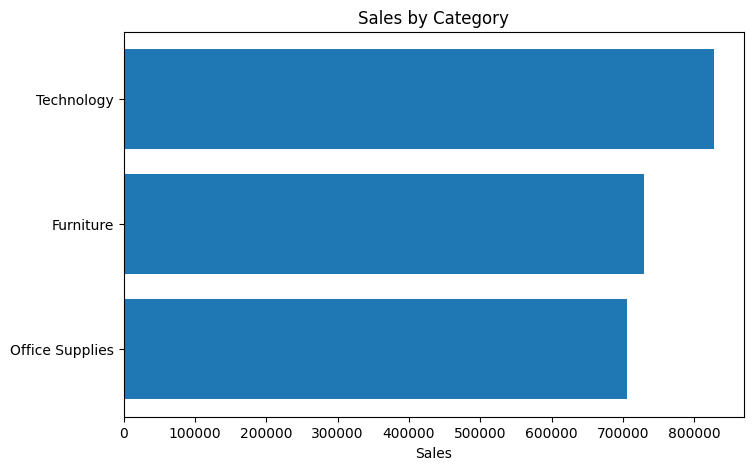

In [ ]:
sales_category = df.groupby('Category')['Sales'].sum().sort_values()

plt.figure(figsize=(8,5))
plt.barh(sales_category.index, sales_category.values)
plt.title("Sales by Category")
plt.xlabel("Sales")
plt.show()

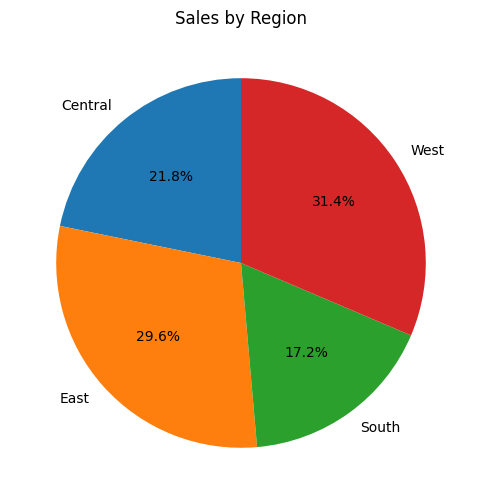

In [ ]:
sales_region = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(6,6))
plt.pie(
    sales_region,
    labels=sales_region.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Sales by Region")
plt.show()

In [ ]:
sales_segment = df.groupby("Segment")["Sales"].sum()
print(sales_segment)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


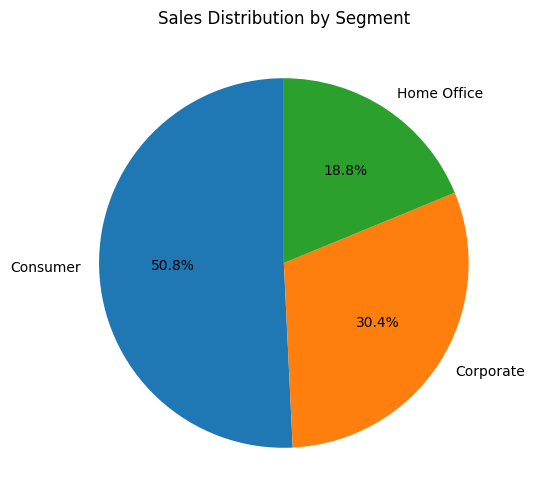

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    sales_segment.values,
    labels=sales_segment.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Sales Distribution by Segment")
plt.show()

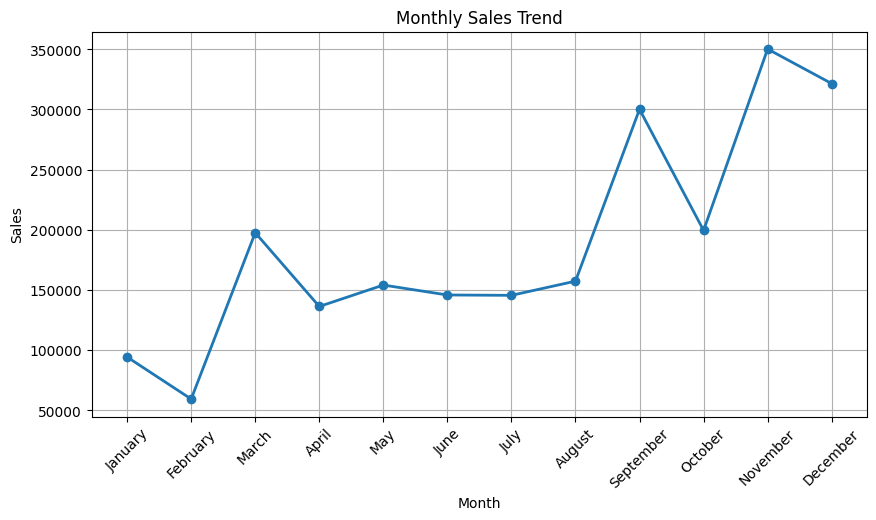

In [ ]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly_sales = df.groupby('Month_Name')['Sales'].sum()
monthly_sales = monthly_sales.reindex(month_order)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

/tmp/ipykernel_666/4002821606.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


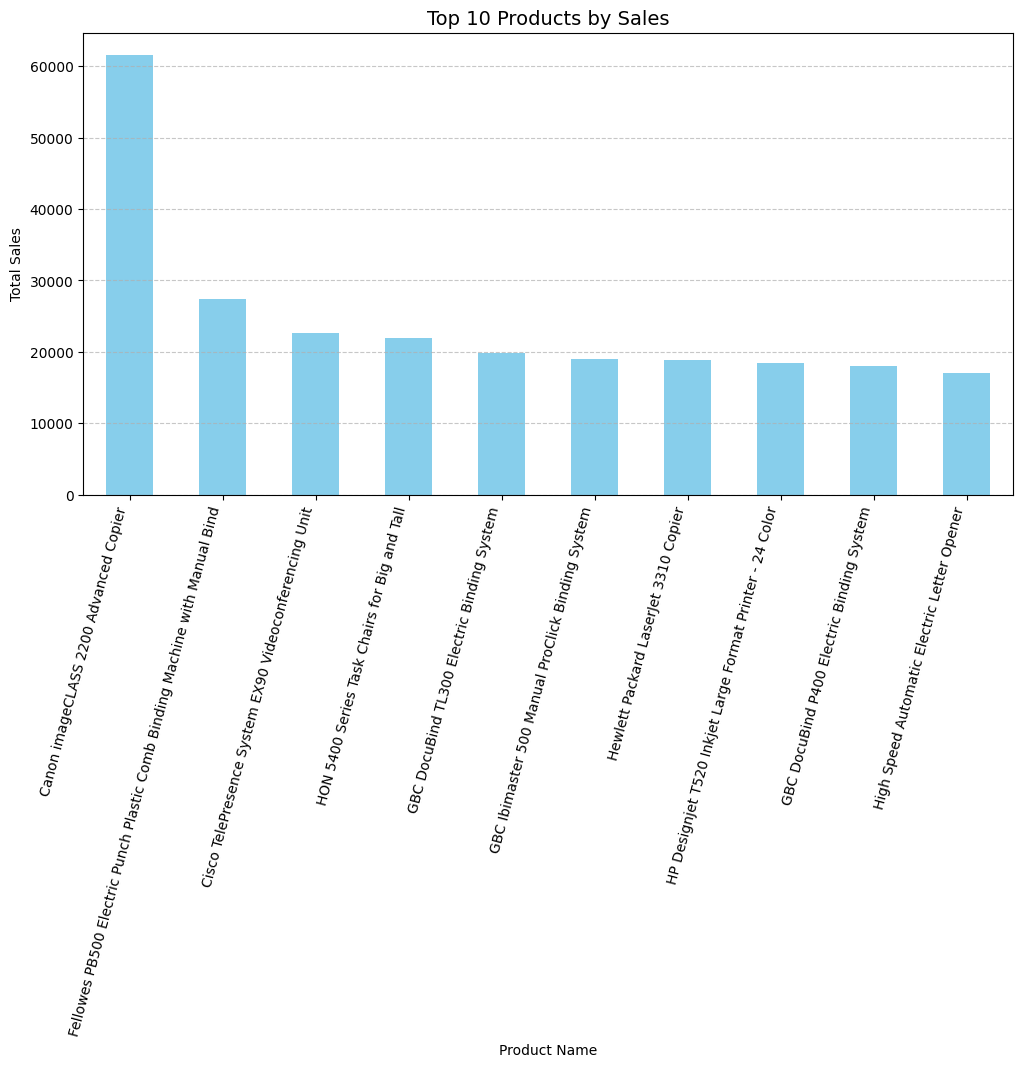

In [ ]:
top10_products = (
    df.groupby("Product_Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

# Plot
plt.figure(figsize=(12,6))
top10_products.plot(kind="bar", color="skyblue")

plt.title("Top 10 Products by Sales", fontsize=14)
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=75, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

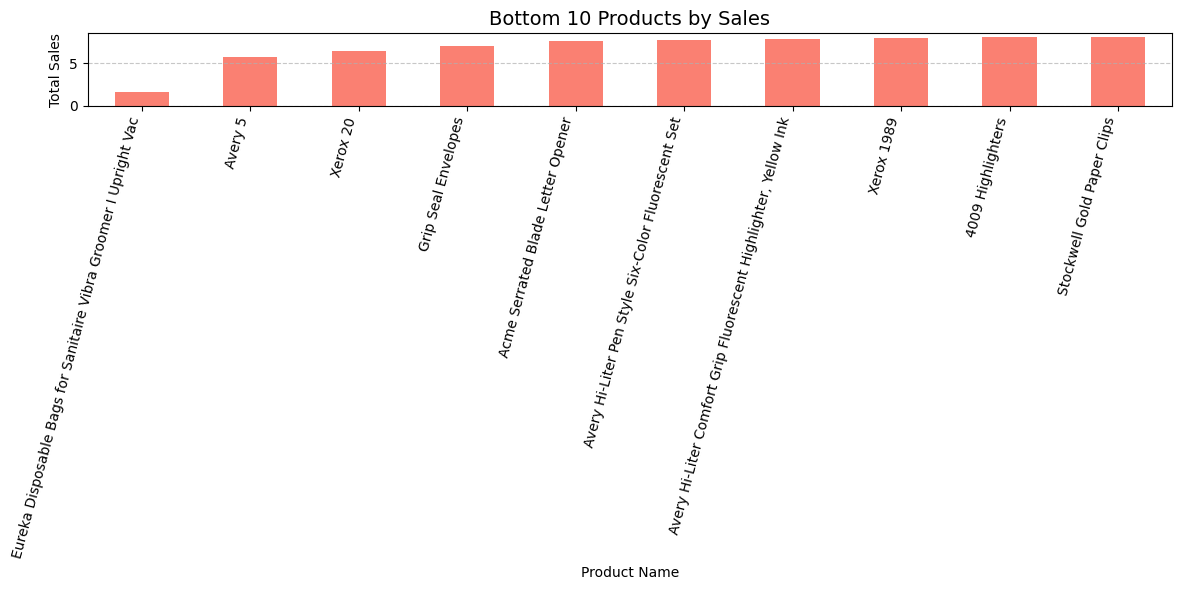

In [ ]:
bottom10_products = (
    df.groupby("Product_Name")["Sales"]
      .sum()
      .sort_values(ascending=True)
      .head(10)
)

# Plot
plt.figure(figsize=(12,6))
bottom10_products.plot(kind="bar", color="salmon")

plt.title("Bottom 10 Products by Sales", fontsize=14)
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=75, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()